<a href="https://colab.research.google.com/github/dharani043/ML_PROJECTS/blob/main/Food_Quality_Analyze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODAL TRAINING

  - Data collection
  - Data cleaning and pre-processing
  - Data visualizaton
  - Splitting the data for train and test
  - Modal Selection
  - Modal train
  - Test the modal
  - Build a predictive system

In [92]:
#importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [93]:
#importing the data
df = pd.read_csv('food_quality_balanced.csv')

In [94]:
df.head()

,ID,Food_Type,Ethanol(ppm),Methane(ppm),CO2(ppm),pH,Freshness_Label
0,1,Yogurt,19.840258,19.018460,597.424502,6.736994,Fresh
1,1,Yogurt,24.503265,22.861429,683.857609,6.660218,Slightly Spoiled
2,1,Yogurt,29.138006,31.462817,776.178773,6.394968,Spoiled
3,1,Yogurt,37.967949,42.503083,950.661750,6.158349,Rotten
4,1,Yogurt,18.934775,17.716455,637.065938,7.015317,Fresh


In [95]:
df.shape

(120000, 7)

In [96]:
df.tail()

,ID,Food_Type,Ethanol(ppm),Methane(ppm),CO2(ppm),pH,Freshness_Label
119995,300,Mango,699.816694,316.994290,4829.324971,3.914442,Rotten
119996,300,Mango,396.708240,139.681342,3048.304900,4.565168,Fresh
119997,300,Mango,477.283168,168.165027,3501.689254,4.559505,Slightly Spoiled
119998,300,Mango,595.908308,222.943024,3962.702277,4.246444,Spoiled
119999,300,Mango,793.733577,306.750556,4879.615749,4.033515,Rotten


In [97]:
#finding if null values exists
df.isnull().sum()

,0
ID,0
Food_Type,0
Ethanol(ppm),0
Methane(ppm),0
CO2(ppm),0
pH,0
Freshness_Label,0


In [98]:
#statistical measurements
df.describe()

,ID,Ethanol(ppm),Methane(ppm),CO2(ppm),pH
count,120000.00000,120000.000000,120000.000000,120000.000000,120000.000000
mean,150.50000,175.537316,90.537678,2071.609495,5.754396
std,86.60242,178.762951,84.910967,1706.267661,0.945241
min,1.00000,8.298365,3.865186,255.351030,3.180335
25%,75.75000,45.440260,28.942001,765.453498,5.079637
50%,150.50000,104.042502,59.908753,1411.260805,5.958232
75%,225.25000,245.895383,125.983515,2926.881732,6.517499
max,300.00000,925.163481,507.166433,8978.141366,7.685351


In [99]:
# Print a concise summary of a DataFrame.

#This method prints information about a DataFrame including the index dtype and columns, non-null values and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               120000 non-null  int64  
 1   Food_Type        120000 non-null  object 
 2   Ethanol(ppm)     120000 non-null  float64
 3   Methane(ppm)     120000 non-null  float64
 4   CO2(ppm)         120000 non-null  float64
 5   pH               120000 non-null  float64
 6   Freshness_Label  120000 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 6.4+ MB


In [100]:
#to find in each food how many data we have
df['Food_Type'].value_counts()

,count
Food_Type,
Butter,7200
Apple,7200
Mango,6800
Grapes,5600
Bread,5200
Spinach,5200
Pork,5200
Potato,4800
Broccoli,4400


<Axes: xlabel='Food_Type', ylabel='count'>

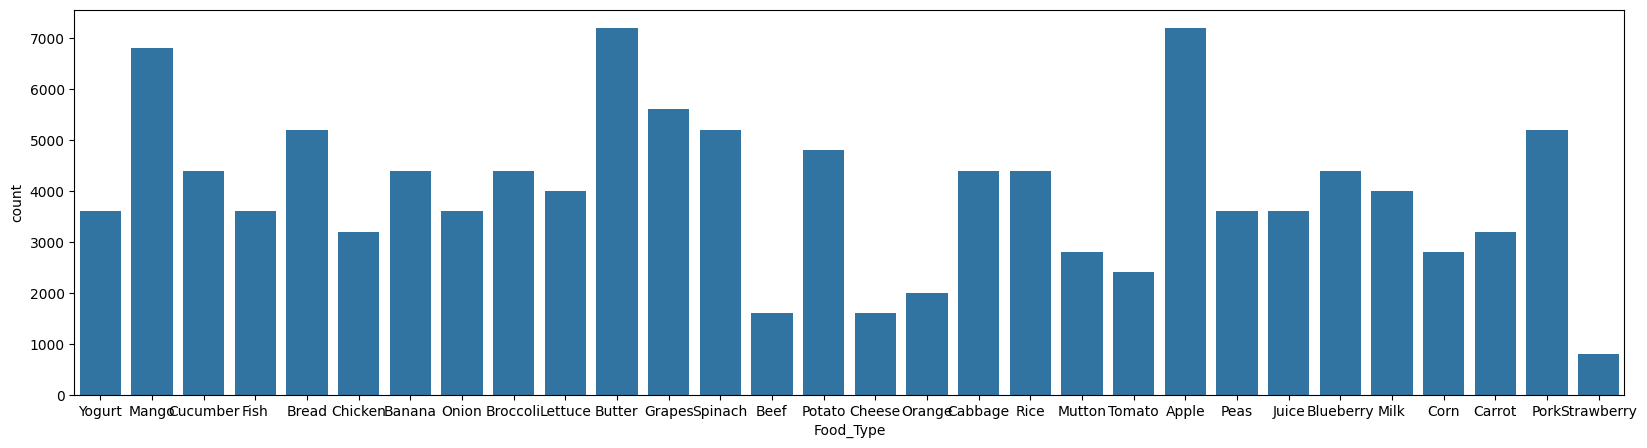

In [101]:
plt.figure(figsize=(20,5))
sns.countplot(x='Food_Type',data=df)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               120000 non-null  int64  
 1   Food_Type        120000 non-null  object 
 2   Ethanol(ppm)     120000 non-null  float64
 3   Methane(ppm)     120000 non-null  float64
 4   CO2(ppm)         120000 non-null  float64
 5   pH               120000 non-null  float64
 6   Freshness_Label  120000 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 6.4+ MB


In [103]:
food_le = LabelEncoder()
food_le.fit(df['Food_Type']) # Fit the encoder to the Food_Type column
food_labels = dict(zip(food_le.classes_, food_le.transform(food_le.classes_)))

freshness_le = LabelEncoder()
freshness_le.fit(df['Freshness_Label']) # Fit the encoder to the Freshness_Label column
freshness_mapping = dict(zip(freshness_le.transform(freshness_le.classes_), freshness_le.classes_))

In [104]:
le = LabelEncoder()
# Create a new column for the numerical food type
df['Food_Type_Num'] = le.fit_transform(df['Food_Type'])
df['Freshness_Num_Label']=le.fit_transform(df['Freshness_Label'])

In [105]:
df['Food_Type'].value_counts()

,count
Food_Type,
Butter,7200
Apple,7200
Mango,6800
Grapes,5600
Bread,5200
Spinach,5200
Pork,5200
Potato,4800
Broccoli,4400


In [106]:
df['Freshness_Label'].value_counts()

,count
Freshness_Label,
Fresh,30000
Slightly Spoiled,30000
Spoiled,30000
Rotten,30000


In [107]:
df.head()

,ID,Food_Type,Ethanol(ppm),Methane(ppm),CO2(ppm),pH,Freshness_Label,Food_Type_Num,Freshness_Num_Label
0,1,Yogurt,19.840258,19.018460,597.424502,6.736994,Fresh,29,0
1,1,Yogurt,24.503265,22.861429,683.857609,6.660218,Slightly Spoiled,29,2
2,1,Yogurt,29.138006,31.462817,776.178773,6.394968,Spoiled,29,3
3,1,Yogurt,37.967949,42.503083,950.661750,6.158349,Rotten,29,1
4,1,Yogurt,18.934775,17.716455,637.065938,7.015317,Fresh,29,0


In [108]:
#splitting the labled data
x=df.drop(columns=['Freshness_Label','Freshness_Num_Label','Food_Type','ID'],axis=1)
y=df['Freshness_Num_Label']

In [109]:
print(x)

        Ethanol(ppm)  Methane(ppm)     CO2(ppm)        pH  Food_Type_Num
0          19.840258     19.018460   597.424502  6.736994             29
1          24.503265     22.861429   683.857609  6.660218             29
2          29.138006     31.462817   776.178773  6.394968             29
3          37.967949     42.503083   950.661750  6.158349             29
4          18.934775     17.716455   637.065938  7.015317             29
...              ...           ...          ...       ...            ...
119995    699.816694    316.994290  4829.324971  3.914442             17
119996    396.708240    139.681342  3048.304900  4.565168             17
119997    477.283168    168.165027  3501.689254  4.559505             17
119998    595.908308    222.943024  3962.702277  4.246444             17
119999    793.733577    306.750556  4879.615749  4.033515             17

[120000 rows x 5 columns]


In [110]:
print(y)

0         0
1         2
2         3
3         1
4         0
         ..
119995    1
119996    0
119997    2
119998    3
119999    1
Name: Freshness_Num_Label, Length: 120000, dtype: int64


In [111]:
#train,test data split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)

In [112]:
print(x_train)
print(y_train)

        Ethanol(ppm)  Methane(ppm)     CO2(ppm)        pH  Food_Type_Num
34540      82.404018     34.278516   838.920341  6.355109              6
105561    160.996818     65.753634  2269.911655  5.460953              5
16454     119.819314     48.528115  1419.324336  5.318549             13
62296     141.720392     43.434919  1319.354861  5.863581              6
11309      44.128191     34.716274   753.982143  6.566895             21
...              ...           ...          ...       ...            ...
5520      416.704401    140.539358  3134.798993  4.861974              4
101350    530.284249    183.447988  6781.119771  3.769110              4
20463      77.534414     12.495568  1049.153430  6.898127              3
18638     174.615220    106.469477  2648.955827  6.003133             15
35683     764.297172    423.774162  5034.020438  4.430352             20

[96000 rows x 5 columns]
34540     0
105561    2
16454     3
62296     0
11309     2
         ..
5520      0
101350    3
20

MODAL SELECTION USING GRID SEARCH CV

In [113]:
# # ✅ IMPORT LIBRARIES
# import pandas as pd
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import GaussianNB
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

# # ✅ MODEL-HYPERPARAMETER MAPPING FOR CLASSIFICATION
# classification_models = {

#     "Random Forest": {
#         "model": RandomForestClassifier(random_state=0),
#         "params": {
#             "n_estimators": [100, 200],
#             "max_depth": [None],
#             "min_samples_split": [2, 5],
#             "min_samples_leaf": [1]
#         }
#     },
#     "XGBoost": {
#         "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
#         "params": {
#             "n_estimators": [100, 200],
#             "learning_rate": [0.01, 0.1],
#             "max_depth": [3, 5],
#             "subsample": [0.8, 1.0]
#         }
#     },
# }

# # ✅ TUNING FUNCTION (ON TRAINING DATA)
# def tune_models(x_train, y_train, model_grid):
#     results = []
#     for name, config in model_grid.items():
#         print(f"Tuning {name}...")
#         grid = GridSearchCV(config['model'], config['params'], cv=2)
#         grid.fit(x_train, y_train)
#         test_score = grid.score(x_test, y_test)  # evaluate on test data

#         results.append({
#             "Model": name,
#             "Best CV Score": round(grid.best_score_ * 100, 2),
#             "Test Accuracy": round(test_score * 100, 2),
#             "Best Params": grid.best_params_
#         })
#     return pd.DataFrame(results)

# # ✅ RUN TUNING
# classification_results = tune_models(x_train, y_train, classification_models)


In [114]:
# ✅ DISPLAY RESULTS
# print("\n🔍 Classification Model Tuning Results:\n")
# print(classification_results)

In [115]:
# Modal train
classifier = RandomForestClassifier(max_depth=None,min_samples_leaf=1,min_samples_split=2,n_estimators=100, random_state=0)
classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=0)

In [116]:
#finding the accuracy Score on Training data
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [117]:
#finding the accuracy Score on Test data
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.9770416666666667


In [118]:
# #building the predictive System
# #    Ethanol(ppm)  Methane(ppm)     CO2(ppm)        pH  Food_Type_Num
# # input_data = (19.840258018568647	,19.018459604206942	,597.4245024370645	,6.7369942344447304,'Yogurt')

# Ethanol=input('Enter the value of Ethanol(ppm): ')
# Methane=input('Enter the value of Methane(ppm): ')
# CO2=input('Enter the value of CO2(ppm): ')
# pH=input('Enter the value of pH: ')
# food_type=input('Enter the food type: ') # user give like apple or Yogurt

# #food type convert to numerical value
# food_type_converted=food_labes[food_type]
# input_data = (Ethanol,Methane,CO2,pH,food_type_converted)
# # Convert the input data to a numpy array
# input_data_as_numpy_array = np.asarray(input_data)

# # Reshape the numpy array as we are predicting for one instance
# input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# # Make the prediction
# prediction = classifier.predict(input_data_reshaped)

# # Map the numerical prediction back to the original freshness label
# # Get the unique freshness labels from the original dataframe to ensure correct mapping
# freshness_labels = df['Freshness_Label'].unique()

# # Create a mapping from numerical label to original label
# label_mapping = {i: label for i, label in enumerate(freshness_labels)}

# predicted_label = label_mapping[prediction[0]]

# print(f'The predicted freshness label is: {predicted_label} (Numerical prediction: {prediction[0]})')

In [119]:
# ================== Predictive System ==================

import numpy as np

# Example: dictionary created when encoding
# food_labels = {'Apple': 0, 'Banana': 1, 'Yogurt': 2, ...}
# freshness_mapping = {0: 'Fresh', 1: 'Stale', 2: 'Rotten', ...}

# --- Take user input ---
Ethanol = float(input('Enter the value of Ethanol(ppm): '))
Methane = float(input('Enter the value of Methane(ppm): '))
CO2 = float(input('Enter the value of CO2(ppm): '))
pH = float(input('Enter the value of pH: '))
food_type = input('Enter the food Name: ')   # e.g., "Yogurt"

# --- Convert food type to numeric ---
if food_type in food_labels:
    food_type_converted = food_labels[food_type]
else:
    raise ValueError(f"Unknown food type: {food_type}. Available: {list(food_labels.keys())}")

# --- Prepare input data ---
input_data = (Ethanol, Methane, CO2, pH, food_type_converted)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)

# --- Predict ---
prediction_num = classifier.predict(input_data_as_numpy_array)[0]

# --- Convert prediction back to freshness label ---
if prediction_num in freshness_mapping:
    predicted_label = freshness_mapping[prediction_num]
else:
    predicted_label = "Unknown"

print(f'The predicted freshness label is: {predicted_label} (Numerical prediction: {prediction_num})')


Enter the value of Ethanol(ppm): 539.3487
Enter the value of Methane(ppm): 286.7611
Enter the value of CO2(ppm): 6838.57
Enter the value of pH: 3.614104
Enter the food type: Grapes
The predicted freshness label is: Rotten (Numerical prediction: 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
